# Phase 1: Data Preprocessing

# Step 1: Import necessary libraries

In [1]:
# Step 1: Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tabulate import tabulate
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder, OneHotEncoder

from scipy import stats

import random
import os

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# Set display options for better viewing
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
%matplotlib inline

# Step 2: Read Dataset

In [2]:
# Step 2: Read Dataset
try:
    df = pd.read_csv('ALLFLOWMETER_HIKARI2021.csv')
    print("Dataset loaded successfully!")
except FileNotFoundError:
    print("File not found. Please check the file path.")
    
# Display first few rows
print("\n=== Display first few rows ===")
df.head()

Dataset loaded successfully!

=== Display first few rows ===


,Unnamed: 0.1,Unnamed: 0,uid,originh,originp,responh,responp,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec,down_up_ratio,fwd_header_size_tot,fwd_header_size_min,fwd_header_size_max,bwd_header_size_tot,bwd_header_size_min,bwd_header_size_max,flow_FIN_flag_count,flow_SYN_flag_count,flow_RST_flag_count,fwd_PSH_flag_count,bwd_PSH_flag_count,flow_ACK_flag_count,fwd_URG_flag_count,bwd_URG_flag_count,flow_CWR_flag_count,flow_ECE_flag_count,fwd_pkts_payload.min,fwd_pkts_payload.max,fwd_pkts_payload.tot,fwd_pkts_payload.avg,fwd_pkts_payload.std,bwd_pkts_payload.min,bwd_pkts_payload.max,bwd_pkts_payload.tot,bwd_pkts_payload.avg,bwd_pkts_payload.std,flow_pkts_payload.min,flow_pkts_payload.max,flow_pkts_payload.tot,flow_pkts_payload.avg,flow_pkts_payload.std,fwd_iat.min,fwd_iat.max,fwd_iat.tot,fwd_iat.avg,fwd_iat.std,bwd_iat.min,bwd_iat.max,bwd_iat.tot,bwd_iat.avg,bwd_iat.std,flow_iat.min,flow_iat.max,flow_iat.tot,flow_iat.avg,flow_iat.std,payload_bytes_per_second,fwd_subflow_pkts,bwd_subflow_pkts,fwd_subflow_bytes,bwd_subflow_bytes,fwd_bulk_bytes,bwd_bulk_bytes,fwd_bulk_packets,bwd_bulk_packets,fwd_bulk_rate,bwd_bulk_rate,active.min,active.max,active.tot,active.avg,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,traffic_category,Label
0,0,0,Cg61Jch3vdz9DBptj,103.255.15.23,13316,128.199.242.104,443,2.207588,15,14,6,6,6.794746,6.341763,13.136509,0.933333,464,20,40,492,32,44,2,2,2,6,5,26,0,0,0,0,0.0,742.0,1826.0,121.733333,220.736581,0.0,1448.0,5025.0,358.928571,552.239840,0.0,1448.0,6851.0,236.241379,424.859275,18.119812,1.963762e+06,2.207603e+06,1.576859e+05,5.205052e+05,7.867813,2.032929e+06,2.177950e+06,1.675346e+05,5.606267e+05,7.867813,1.963762e+06,2.207603e+06,78842.963491,3.696378e+05,3103.387105,7.5,7.0,913.0,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.207603e+06,2.207603e+06,2.207603e+06,2.207603e+06,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,29200,65160,0,Bruteforce-XML,1
1,1,1,CdRIlqLWdj35Y9vW9,103.255.15.23,13318,128.199.242.104,443,15.624266,15,14,6,6,0.960045,0.896042,1.856087,0.933333,488,20,44,468,32,44,2,2,2,6,5,26,0,0,0,0,0.0,745.0,1829.0,121.933333,221.339257,0.0,1448.0,5025.0,358.928571,552.239840,0.0,1448.0,6854.0,236.344828,424.987166,20.980835,1.534300e+07,1.562428e+07,1.116020e+06,4.094889e+06,20.980835,1.541144e+07,1.559517e+07,1.199628e+06,4.270148e+06,10.013580,1.534300e+07,1.562428e+07,558009.896960,2.897622e+06,438.676603,7.5,7.0,914.5,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.883792e+04,2.524381e+05,2.812760e+05,1.406380e+05,158109.181742,1.534300e+07,1.534300e+07,1.534300e+07,1.534300e+07,0.0,29200,65160,0,Bruteforce-XML,1
2,2,2,CLzp9Khd0Y09Qkgrg,103.255.15.23,13320,128.199.242.104,443,12.203357,14,13,6,5,1.147225,1.065281,2.212506,0.928571,432,20,40,448,32,44,2,2,2,6,5,24,0,0,0,0,0.0,744.0,1828.0,130.571429,226.803444,0.0,2896.0,5025.0,386.538462,817.479013,0.0,2896.0,6853.0,253.814815,592.570284,36.001205,1.196814e+07,1.220338e+07,9.387216e+05,3.314032e+06,15.020370,1.203674e+07,1.217482e+07,1.014569e+06,3.471107e+06,15.020370,1.196814e+07,1.220338e+07,469360.810060,2.345336e+06,561.566789,7.0,6.5,914.0,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.891302e+04,2.063251e+05,2.352381e+05,1.176190e+05,125449.251656,1.196814e+07,1.196814e+07,1.196814e+07,1.196814e+07,0.0,29200,65160,0,Bruteforce-XML,1
3,3,3,Cnf1YA4iLB4CSNWB88,103.255.15.23,13322,128.199.242.104,443,9.992448,14,13,6,5,1.401058,1.300983,2.702041,0.928571,432,20,40,436,32,44,2,2,2,6,5,24,0,0,0,0,0.0,744.0,1828.0,130.571429,226.803444,0.0,2896.0,5025.0,386.538462,817.479013,0.0,2896.0,6853.0,253.814815,592.570284,50.067902,9.759205e+06,9.992470e+06,7.686515e+05,2.701448e+06,20.980835,9.828447e+06,9.963348e+06,8.302790e+05,2.833716e+06,20.980835,9.759205e+06,9.992470e+06,384325.770231,1.912152e+06,685.817940,7.0,6.5,914.0,2512.5,0.0,0.0,0.0,0.0,0.0,0.0,2.952909e+04,2.037361e+05,2.332652e+05,1.166326e+05,123182.

In [3]:
# Display last few rows
print("\n=== Display last few rows ===")
df.tail()


=== Display last few rows ===


,Unnamed: 0.1,Unnamed: 0,uid,originh,originp,responh,responp,flow_duration,fwd_pkts_tot,bwd_pkts_tot,fwd_data_pkts_tot,bwd_data_pkts_tot,fwd_pkts_per_sec,bwd_pkts_per_sec,flow_pkts_per_sec,down_up_ratio,fwd_header_size_tot,fwd_header_size_min,fwd_header_size_max,bwd_header_size_tot,bwd_header_size_min,bwd_header_size_max,flow_FIN_flag_count,flow_SYN_flag_count,flow_RST_flag_count,fwd_PSH_flag_count,bwd_PSH_flag_count,flow_ACK_flag_count,fwd_URG_flag_count,bwd_URG_flag_count,flow_CWR_flag_count,flow_ECE_flag_count,fwd_pkts_payload.min,fwd_pkts_payload.max,fwd_pkts_payload.tot,fwd_pkts_payload.avg,fwd_pkts_payload.std,bwd_pkts_payload.min,bwd_pkts_payload.max,bwd_pkts_payload.tot,bwd_pkts_payload.avg,bwd_pkts_payload.std,flow_pkts_payload.min,flow_pkts_payload.max,flow_pkts_payload.tot,flow_pkts_payload.avg,flow_pkts_payload.std,fwd_iat.min,fwd_iat.max,fwd_iat.tot,fwd_iat.avg,fwd_iat.std,bwd_iat.min,bwd_iat.max,bwd_iat.tot,bwd_iat.avg,bwd_iat.std,flow_iat.min,flow_iat.max,flow_iat.tot,flow_iat.avg,flow_iat.std,payload_bytes_per_second,fwd_subflow_pkts,bwd_subflow_pkts,fwd_subflow_bytes,bwd_subflow_bytes,fwd_bulk_bytes,bwd_bulk_bytes,fwd_bulk_packets,bwd_bulk_packets,fwd_bulk_rate,bwd_bulk_rate,active.min,active.max,active.tot,active.avg,active.std,idle.min,idle.max,idle.tot,idle.avg,idle.std,fwd_init_window_size,bwd_init_window_size,fwd_last_window_size,traffic_category,Label
555273,555273,280838,C9b6Aa2csiogu3vVp9,103.255.15.42,138,103.255.15.255,138,0.0,1,0,1,0,0.0,0.0,0.0,0.0,8,8,8,0,0,0,0,0,0,0,0,0,0,0,0,0,201.0,201.0,201.0,201.0,0.0,0.0,0.0,0.0,0.0,0.0,201.0,201.0,201.0,201.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,201.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,XMRIGCC CryptoMiner,1
555274,555274,280839,CGDT4r4PAbp3mvaI6k,103.255.15.42,138,103.255.15.255,138,0.0,1,0,1,0,0.0,0.0,0.0,0.0,8,8,8,0,0,0,0,0,0,0,0,0,0,0,0,0,201.0,201.0,201.0,201.0,0.0,0.0,0.0,0.0,0.0,0.0,201.0,201.0,201.0,201.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,201.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,XMRIGCC CryptoMiner,1
555275,555275,280840,CJUxTk4Qd0kHliUKR9,103.255.15.42,138,103.255.15.255,138,0.0,1,0,1,0,0.0,0.0,0.0,0.0,8,8,8,0,0,0,0,0,0,0,0,0,0,0,0,0,201.0,201.0,201.0,201.0,0.0,0.0,0.0,0.0,0.0,0.0,201.0,201.0,201.0,201.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,201.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,XMRIGCC CryptoMiner,1
555276,555276,280841,CknUJi2R1iYJG3li3k,103.255.15.42,138,103.255.15.255,138,0.0,1,0,1,0,0.0,0.0,0.0,0.0,8,8,8,0,0,0,0,0,0,0,0,0,0,0,0,0,201.0,201.0,201.0,201.0,0.0,0.0,0.0,0.0,0.0,0.0,201.0,201.0,201.0,201.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,201.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,XMRIGCC CryptoMiner,1
555277,555277,280842,C82mlb2i3zEzpeTGQk,103.255.15.42,138,103.255.15.255,138,0.0,1,0,1,0,0.0,0.0,0.0,0.0,8,8,8,0,0,0,0,0,0,0,0,0,0,0,0,0,201.0,201.0,201.0,201.0,0.0,0.0,0.0,0.0,0.0,0.0,201.0,201.0,201.0,201.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,201.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,XMRIGCC CryptoMiner,1


# Step 3: Duplicates & Garbage Value Treatment

In [4]:
# Step 3: Duplicates & Garbage Value Treatment
print("\n=== Duplicates & Garbage Value Treatment ===")

# Remove duplicate rows
initial_rows = df.shape[0]
df = df.drop_duplicates()
final_rows = df.shape[0]
print(f"Removed {initial_rows - final_rows} duplicate rows")

# Check for garbage values in categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    print(f"\nUnique values in {col}:")
    print(df[col].unique())
    
    # Example: Replace common garbage values (customize based on your data)
    garbage_values = ['unknown', '?', '-', 'NA', 'N/A', 'null', 'NaN', '']
    for val in garbage_values:
        if val in df[col].unique():
            mode_val = df[col].mode()[0]
            df[col] = df[col].replace(val, mode_val)
            print(f"Replaced '{val}' with mode '{mode_val}' in {col}")

# Check for impossible numerical values
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in numerical_cols:
    # Example: Replace negative values in columns that should be positive
    if (df[col] < 0).any():
        print(f"\nNegative values found in {col}")
        df[col] = df[col].abs()
        print(f"Converted negative values to positive in {col}")


=== Duplicates & Garbage Value Treatment ===
Removed 0 duplicate rows

Unique values in uid:
['Cg61Jch3vdz9DBptj' 'CdRIlqLWdj35Y9vW9' 'CLzp9Khd0Y09Qkgrg' ...
 'CJUxTk4Qd0kHliUKR9' 'CknUJi2R1iYJG3li3k' 'C82mlb2i3zEzpeTGQk']

Unique values in originh:
['103.255.15.23' '103.255.15.27' '103.255.15.20' ... '128.199.193.172'
 '192.241.215.105' '205.185.126.174']

Unique values in responh:
['128.199.242.104' '128.199.88.81' '103.255.15.23' ... '103.120.247.252'
 '104.18.5.86' '104.18.4.86']

Unique values in traffic_category:
['Bruteforce-XML' 'Bruteforce' 'Background' 'Benign' 'Probing'
 'XMRIGCC CryptoMiner']


# Step 4: Sanity check of data

In [5]:
# Step 4: Sanity check of data
print("\n=== Cybersecurity Data Sanity Check ===")

# 1. Basic Dataset Integrity
print("\n--- Dataset Integrity ---")
print(f"Shape: {df.shape} (Rows: {df.shape[0]}, Columns: {df.shape[1]})")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nMemory Usage: {df.memory_usage().sum()/1024/1024:.2f} MB")

# 2. Cybersecurity Field Validation (Enhanced)
print("\n=== Label Field Validation ===")

if 'Label' in df.columns:
    print("✅ Found Label field")
    
    # Check label values
    unique_labels = sorted(df['Label'].unique())
    print(f"Unique label values: {unique_labels}")
    
    # Basic validation
    if len(unique_labels) == 2:
        print("Binary labels detected (expected for classification)")
    elif len(unique_labels) > 2:
        print("⚠️ Multi-class labels detected")
    else:
        print("⚠️ Only one label value present - check data balance")
    
    # Show distribution
    print("\nLabel distribution/Class Distribution:")
    print(df['Label'].value_counts().to_markdown())
    
else:
    print("❌ CRITICAL: No label field found")
    print("This dataset cannot be used for supervised learning without labels")
    
    # Check for potential alternatives
    potential_labels = ['attack_type', 'malicious', 'anomaly', 'class']
    found_alt = [col for col in potential_labels if col in df.columns]
    
    if found_alt:
        print("\nPotential alternative label fields found:")
        for col in found_alt:
            print(f"- {col} (unique values: {df[col].unique()[:5]}...)")
    else:
        print("\nNo obvious alternative label fields found")

# 3. Null Value Analysis (Enhanced)
null_counts = df.isnull().sum()
null_percent = null_counts/len(df)*100
null_report = pd.DataFrame({'Null Count': null_counts, 'Null Percentage': null_percent})
print("\nNull Value Report:")
print(null_report[null_counts > 0].sort_values('Null Count', ascending=False).to_markdown())

# 4. Duplicate Dimensions Report
dup_count = df.duplicated().sum()
print(f"\nDuplicate Rows: {dup_count} ({dup_count/len(df)*100:.2f}% of data)")

if dup_count > 0:
    dup_rows = df[df.duplicated(keep=False)]
    print("\nDuplicate data dimensions:")
    print(f"Total duplicate rows: {len(dup_rows)}") 
    print(f"Total columns in duplicates: {len(dup_rows.columns)}")

# 5. Packet/Flow Feature Validation (Fixed)
network_features = ['packet_length', 'flow_duration', 'bytes_sent', 'bytes_received']
for feat in network_features:
    if feat in df.columns:
        print(f"\n--- {feat} Validation ---")
        numeric_feat = pd.to_numeric(df[feat], errors='coerce')
        
        print(f"Negative Values: {len(numeric_feat[numeric_feat < 0])}")
        print(f"Zero Values: {len(numeric_feat[numeric_feat == 0])}")
        print(f"99th Percentile: {numeric_feat.quantile(0.99):.2f}")
        print(f"Max Value: {numeric_feat.max():.2f}")

# 6. Network-Specific Sanity Checks
print("\n--- Network Traffic Specific Checks ---")

# Protocol Validation
if 'protocol' in df.columns:
    valid_protocols = ['TCP', 'UDP', 'ICMP', 'HTTP', 'HTTPS']  # Add expected protocols
    invalid_protocols = set(df['protocol'].unique()) - set(valid_protocols)
    print(f"\nUnexpected Protocols: {invalid_protocols if invalid_protocols else 'None'}")

# Port Validation
if 'dst_port' in df.columns:
    invalid_ports = df[(df['dst_port'] < 0) | (df['dst_port'] > 65535)]
    print(f"\nInvalid Port Numbers: {len(invalid_ports)} rows")

# IP Address Validation
for ip_col in ['src_ip', 'dst_ip']:
    if ip_col in df.columns:
        invalid_ips = df[~df[ip_col].str.match(r'^\d{1,3}\.\d{1,3}\.\d{1,3}\.\d{1,3}$', na=False)]
        print(f"\nInvalid {ip_col} formats: {len(invalid_ips)} rows")

# 7. Temporal Data Checks
if 'timestamp' in df.columns:
    print("\n--- Temporal Data Validation ---")
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    print(f"Time Range: {df['timestamp'].min()} to {df['timestamp'].max()}")
    
    # Check for future dates
    future_dates = df[df['timestamp'] > pd.Timestamp.now()]
    print(f"\nFuture Timestamps: {len(future_dates)} rows")

# 8. Data Consistency Checks
print("\n--- Consistency Checks ---")
if all(col in df.columns for col in ['bytes_sent', 'bytes_received', 'total_bytes']):
    inconsistent = df[abs(df['bytes_sent'] + df['bytes_received'] - df['total_bytes']) > 1]
    print(f"\nInconsistent Byte Calculations: {len(inconsistent)} rows")


=== Cybersecurity Data Sanity Check ===

--- Dataset Integrity ---
Shape: (555278, 88) (Rows: 555278, Columns: 88)

Data Types:
Unnamed: 0.1             int64
Unnamed: 0               int64
uid                     object
originh                 object
originp                  int64
                         ...  
fwd_init_window_size     int64
bwd_init_window_size     int64
fwd_last_window_size     int64
traffic_category        object
Label                    int64
Length: 88, dtype: object

Memory Usage: 372.81 MB

=== Label Field Validation ===
✅ Found Label field
Unique label values: [np.int64(0), np.int64(1)]
Binary labels detected (expected for classification)

Label distribution/Class Distribution:
|   Label |   count |
|--------:|--------:|
|       0 |  517582 |
|       1 |   37696 |

Null Value Report:
| Null Count   | Null Percentage   |
|--------------|-------------------|

Duplicate Rows: 0 (0.00% of data)

--- flow_duration Validation ---
Negative Values: 0
Zero Values: 609

# Step 5: Exploratory Data Analysis (EDA)


=== Enhanced Exploratory Data Analysis (Small & Neat) ===

=== Attack Analysis ===

Total records: 555278
Total attacks detected: 37696

Attack distribution:
|   Label |   Count | Percent   |
|---------|---------|-----------|
|       0 |  517582 | 93.21%    |
|       1 |   37696 | 6.79%     |

Numerical columns distributions:


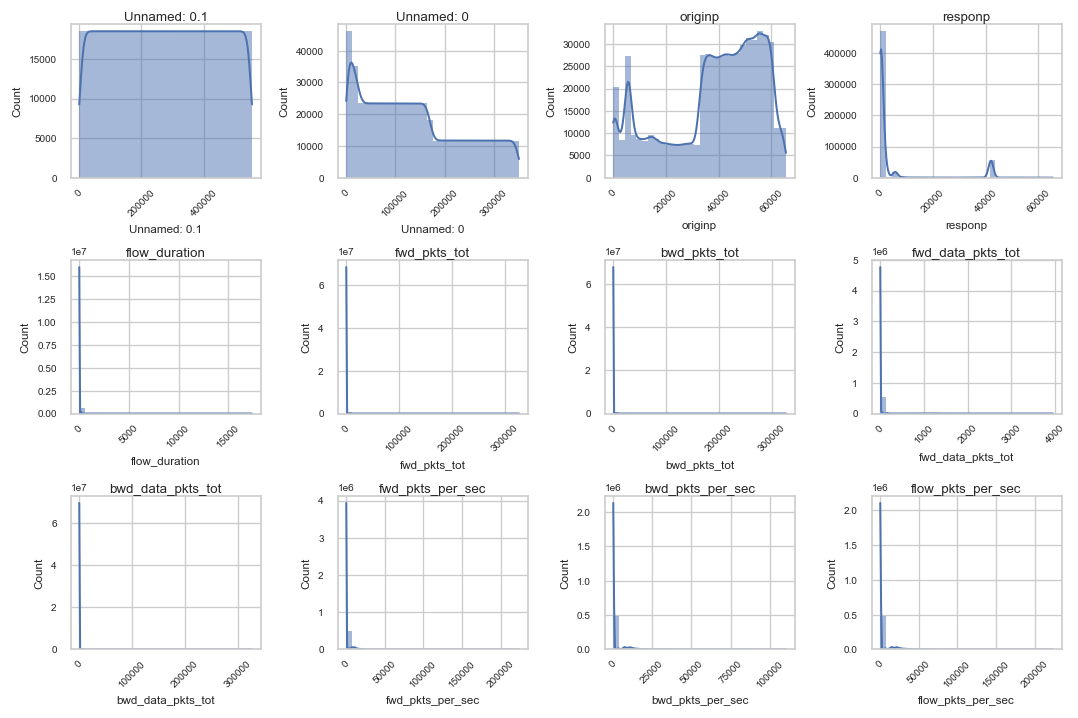


Outlier Detection using Boxplots:
- Unnamed: 0.1: 0 outliers
- Unnamed: 0: 0 outliers
- originp: 0 outliers
- responp: 116890 outliers
- flow_duration: 123666 outliers
- fwd_pkts_tot: 35721 outliers
- bwd_pkts_tot: 30287 outliers
- fwd_data_pkts_tot: 43689 outliers
- bwd_data_pkts_tot: 36750 outliers
- fwd_pkts_per_sec: 83352 outliers
- bwd_pkts_per_sec: 82645 outliers
- flow_pkts_per_sec: 83245 outliers


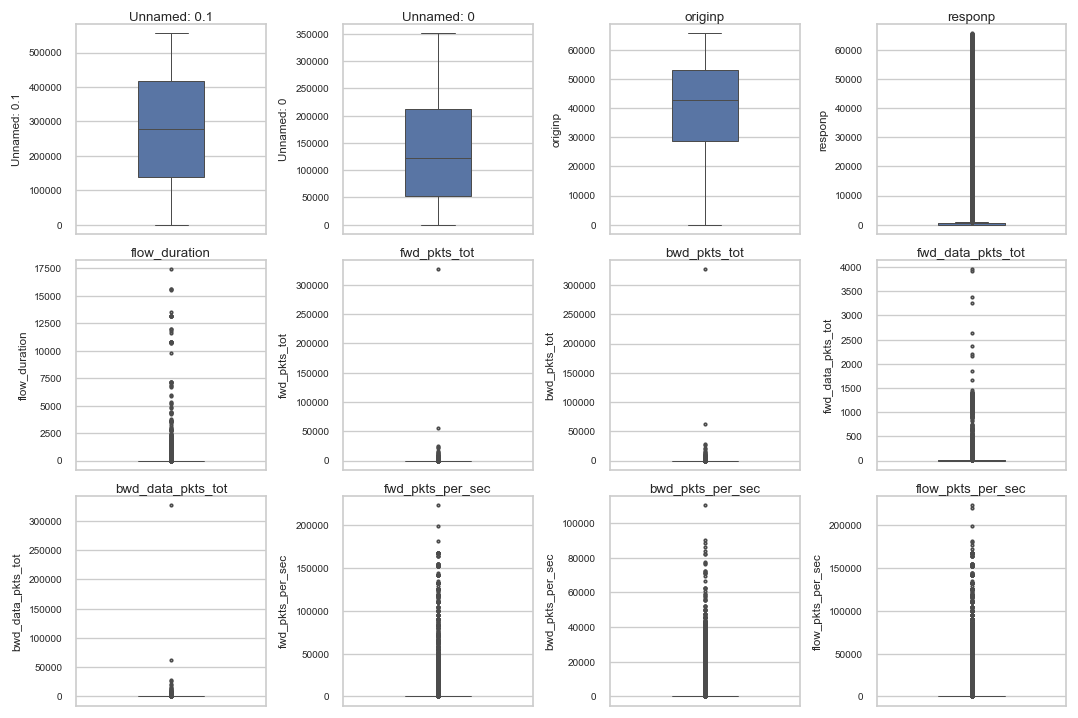


Enhanced Categorical Analysis:

uid value counts (top 20):
| uid                |   Count |
|--------------------|---------|
| C82mlb2i3zEzpeTGQk |       1 |
| Cg61Jch3vdz9DBptj  |       1 |
| CdRIlqLWdj35Y9vW9  |       1 |
| CLzp9Khd0Y09Qkgrg  |       1 |
| Cnf1YA4iLB4CSNWB88 |       1 |
| C4ZKvv3fpO72EAOsJ6 |       1 |
| CyC8D5X7IIG7U95l4  |       1 |
| CEXyM013OxRuUddrS2 |       1 |
| CVFc4q26WLSGblwO2c |       1 |
| CCvZhO2f7ztLs9Hopc |       1 |
| CIPZU1mfhrkqqix49  |       1 |
| CBTv463lWatXHzgmf3 |       1 |
| C87B4VRML4MIzqiFc  |       1 |
| CDqmaw1RdkdRYvaDMk |       1 |
| ChAgWp4SNFDdvIK9Z2 |       1 |
| C96kNe2MN0zfiTvkt4 |       1 |
| ClsT7G4ede0t57kzs6 |       1 |
| ChqPqq2Ssq7ec6i8M2 |       1 |
| CtHjlo2FZB3KF7f3Ab |       1 |
| CX8eO43TzmRWxbn6r4 |       1 |


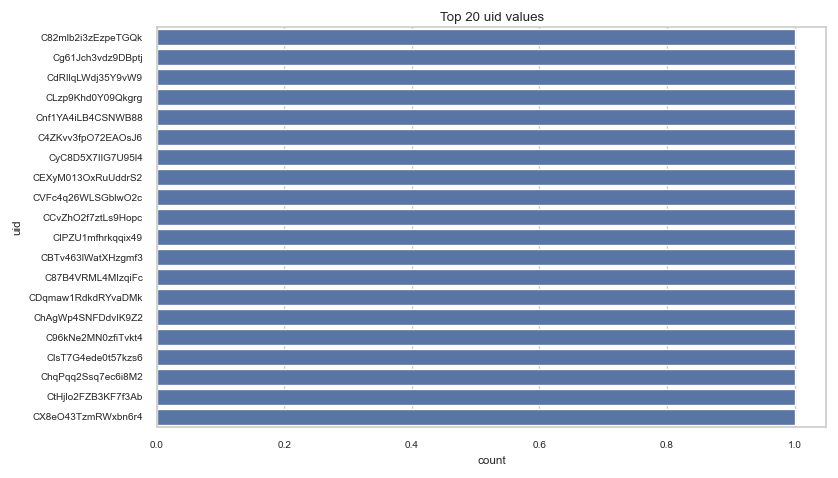


originh value counts (top 20):
| originh                   |   Count |
|---------------------------|---------|
| 103.255.15.23             |  213520 |
| 103.255.15.150            |  182631 |
| 103.255.15.27             |   57488 |
| 103.255.15.20             |   26862 |
| 103.255.15.67             |   14200 |
| fe80::c1a7:7791:969e:3c06 |    7761 |
| 103.255.15.42             |    5839 |
| 103.255.15.21             |    3314 |
| 0.0.0.0                   |    2390 |
| 142.252.253.26            |    2357 |
| 24.212.41.209             |    2182 |
| 103.255.15.146            |    1834 |
| 24.212.71.31              |    1710 |
| 202.169.224.219           |    1646 |
| 103.255.15.15             |    1641 |
| 103.255.15.110            |    1398 |
| 103.255.15.65             |    1314 |
| 100.64.65.78              |    1303 |
| 92.63.197.23              |    1277 |
| 103.255.15.206            |    1262 |


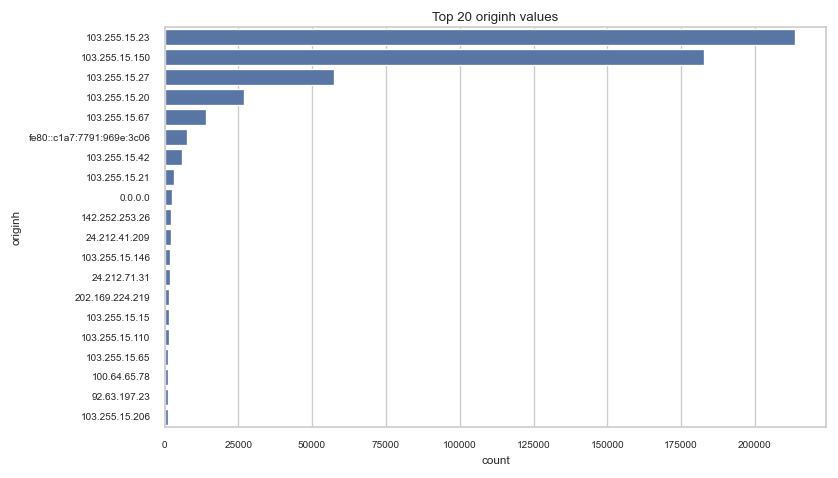


responh value counts (top 20):
| responh            |   Count |
|--------------------|---------|
| 8.8.8.8            |  189666 |
| 128.199.242.104    |   99663 |
| 103.255.15.23      |   90678 |
| 255.255.255.255    |   36528 |
| 103.255.15.255     |   20913 |
| 128.199.88.81      |    7988 |
| 2600:1901:0:38d7:: |    7568 |
| 117.18.237.29      |    6650 |
| 34.107.221.82      |    5497 |
| 103.255.15.150     |    2990 |
| 10.255.254.228     |    2087 |
| 13.227.228.50      |    1702 |
| 13.227.228.95      |    1636 |
| 13.227.228.125     |    1557 |
| 13.227.228.53      |    1552 |
| 13.227.228.83      |    1310 |
| 13.227.228.12      |    1264 |
| 13.227.228.71      |    1262 |
| 13.227.228.6       |    1210 |
| 8.8.4.4            |    1005 |


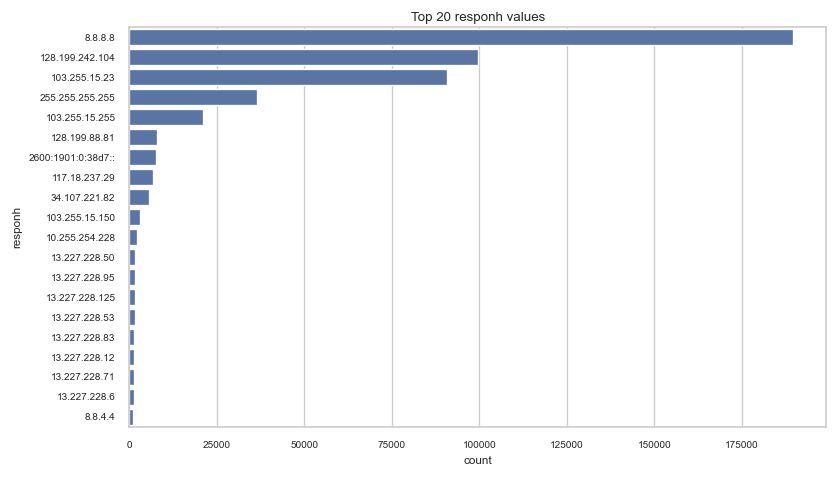


traffic_category value counts (top 20):
| traffic_category    |   Count |
|---------------------|---------|
| Benign              |  347431 |
| Background          |  170151 |
| Probing             |   23388 |
| Bruteforce          |    5884 |
| Bruteforce-XML      |    5145 |
| XMRIGCC CryptoMiner |    3279 |


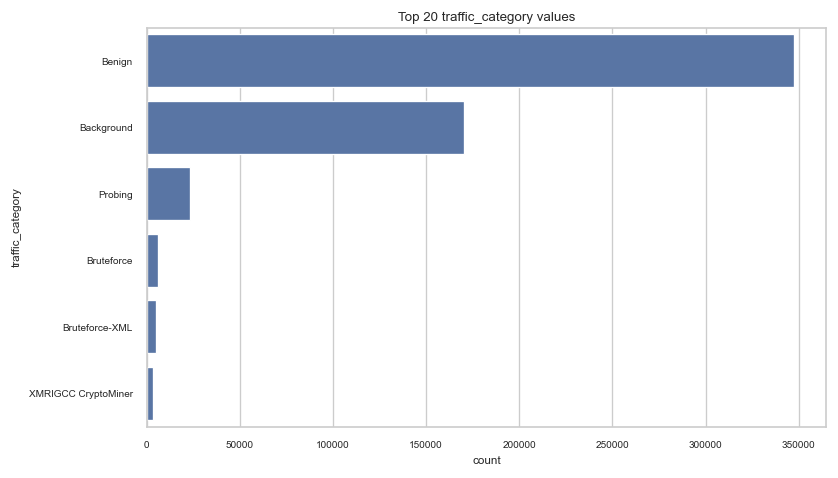


=== Feature Summary Table ===
| Feature                  | Type    |   Unique |   Missing | Samples(≤3)                                             |
|--------------------------|---------|----------|-----------|---------------------------------------------------------|
| Unnamed: 0.1             | int64   |   555278 |         0 | 0, 1, 2                                                 |
| Unnamed: 0               | int64   |   350710 |         0 | 0, 1, 2                                                 |
| uid                      | object  |   555278 |         0 | Cg61Jch3vdz9DBptj, CdRIlqLWdj35Y9vW9, CLzp9Khd0Y09Qkgrg |
| originh                  | object  |     2899 |         0 | 103.255.15.23, 103.255.15.27, 103.255.15.20             |
| originp                  | int64   |    62886 |         0 | 13316, 13318, 13320                                     |
| responh                  | object  |     7991 |         0 | 128.199.242.104, 128.199.88.81, 103.255.15.23           |
| responp

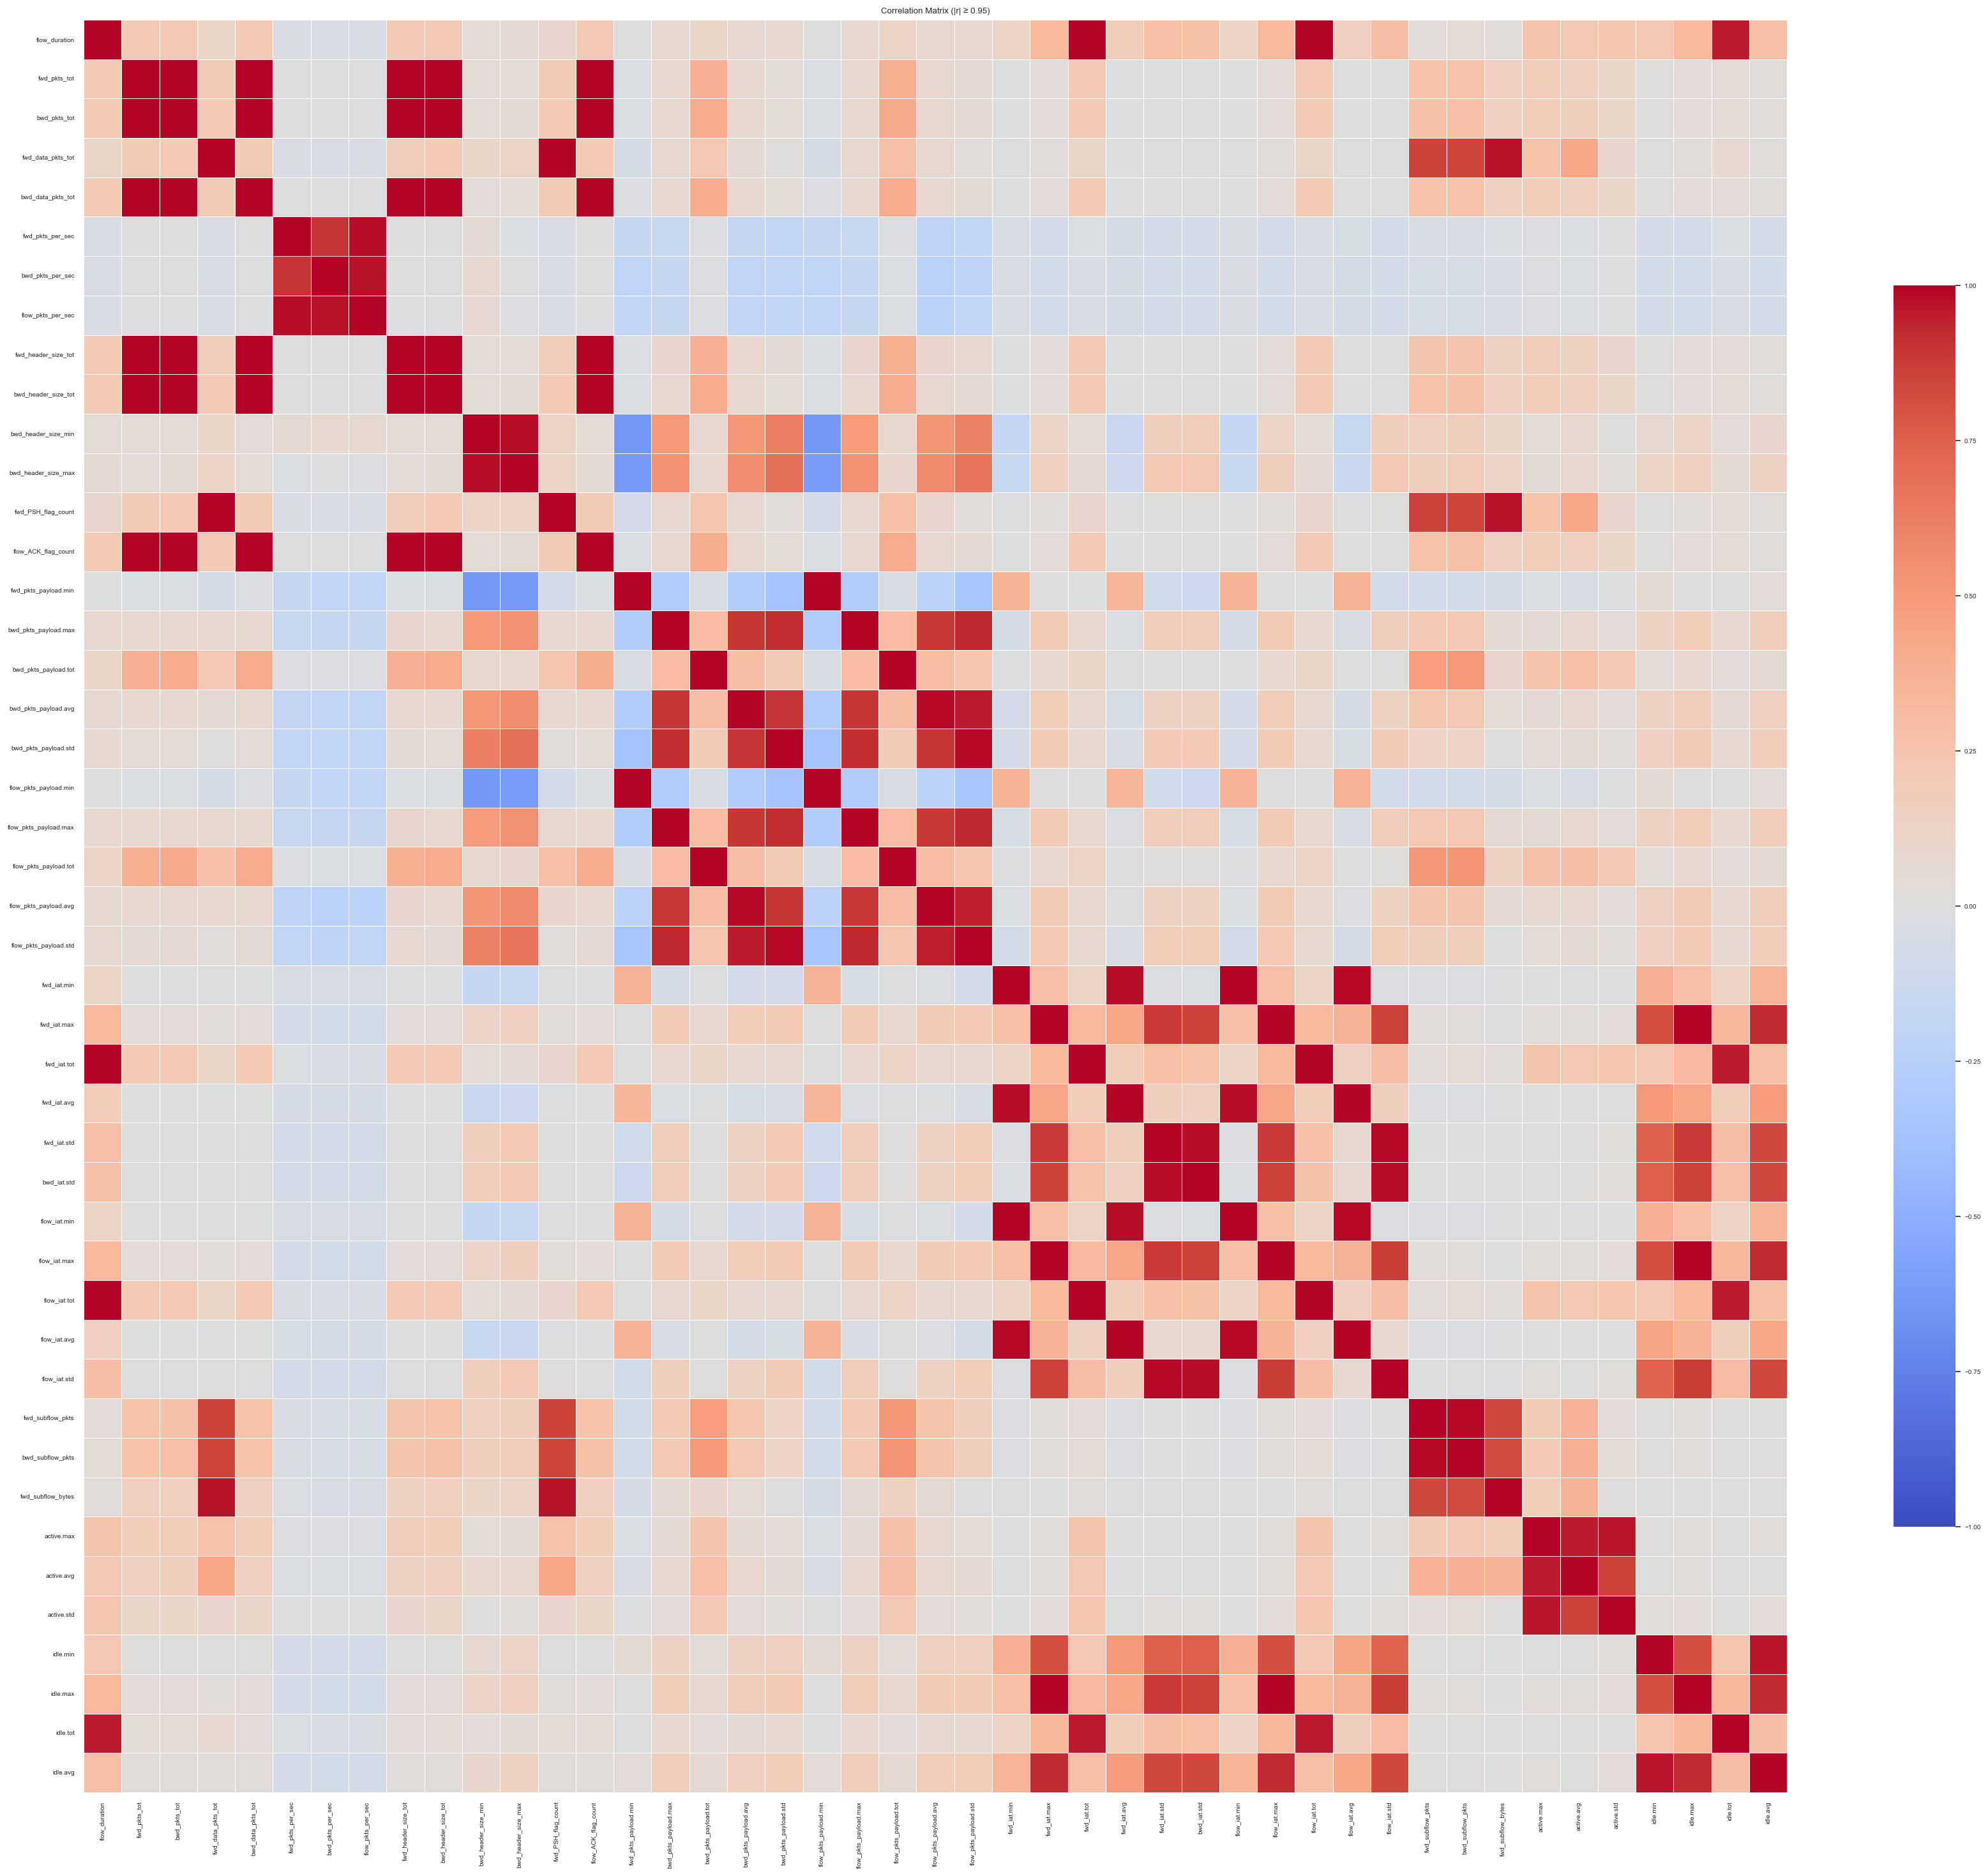


Suggested features to REMOVE so no remaining pair has |r| ≥ 0.95, preferring to KEEP features more associated with 'Label':
['bwd_pkts_tot', 'bwd_header_size_tot', 'idle.tot', 'fwd_iat.min', 'flow_pkts_payload.std', 'bwd_data_pkts_tot', 'idle.max', 'flow_pkts_per_sec', 'flow_iat.min', 'flow_iat.std', 'flow_iat.tot', 'active.max', 'fwd_header_size_tot', 'fwd_data_pkts_tot', 'idle.avg', 'flow_iat.avg', 'fwd_pkts_payload.min', 'flow_iat.max', 'bwd_pkts_payload.max', 'flow_duration', 'bwd_pkts_payload.avg', 'bwd_header_size_max', 'bwd_pkts_payload.tot', 'bwd_subflow_pkts', 'bwd_iat.std', 'fwd_pkts_tot', 'fwd_PSH_flag_count']


In [6]:
# ===== Step 5: EDA =====

import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
import seaborn as sns
import textwrap
import matplotlib.pyplot as plt
%matplotlib inline

# ---- Compact global styles ----
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 120,
    "axes.titlesize": 8, "axes.labelsize": 7,
    "xtick.labelsize": 6, "ytick.labelsize": 6,
    "legend.fontsize": 7, "figure.titlesize": 9
})
pd.set_option("display.width", 100)
pd.set_option("display.max_columns", 0)  # show all cols
pd.set_option("display.max_colwidth", 30)
pd.set_option("display.max_rows", 2000)  # show all features if needed
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

print("\n=== Enhanced Exploratory Data Analysis (Small & Neat) ===")

# 0. Attack Analysis (keep all, print compact table)
print("\n=== Attack Analysis ===")
attack_column = 'Label'
if attack_column in df.columns:
    attack_counts = df[attack_column].value_counts(dropna=False)
    total_records = len(df)
    total_attacks = attack_counts.sum() if attack_column != 'Label' else attack_counts.get(1, 0)

    print(f"\nTotal records: {total_records}")
    print(f"Total attacks detected: {total_attacks}")

    print("\nAttack distribution:")
    attack_dist = pd.DataFrame({
        "Count": attack_counts,
        "Percent": (attack_counts / total_records).map(lambda x: f"{x:.2%}")
    })
    print(attack_dist.to_markdown(tablefmt="github"))

# 1. Numerical Distributions with KDE (same content, smaller figs & fonts)
numerical_cols = df.select_dtypes(include=['int64', 'float64', np.number]).columns
if len(numerical_cols) > 0:
    print("\nNumerical columns distributions:")
    n_show = min(12, len(numerical_cols))
    fig, axes = plt.subplots(3, 4, figsize=(9, 6))  # smaller than 16x10
    axes = axes.flatten()

    for i, col in enumerate(numerical_cols[:n_show]):
        ax = axes[i]
        sns.histplot(df[col], kde=True, bins=30, ax=ax, linewidth=0)
        ax.set_title(col, pad=2)
        ax.tick_params(axis='x', labelrotation=45, pad=1)

    # hide unused axes
    for j in range(n_show, len(axes)):
        axes[j].axis('off')

    plt.tight_layout(pad=0.8)
    plt.show()

# 2. Outlier Detection using Boxplots (same content, smaller figs)
if len(numerical_cols) > 0:
    print("\nOutlier Detection using Boxplots:")
    n_show = min(12, len(numerical_cols))
    fig, axes = plt.subplots(3, 4, figsize=(9, 6))
    axes = axes.flatten()

    for i, col in enumerate(numerical_cols[:n_show]):
        ax = axes[i]
        sns.boxplot(y=df[col], ax=ax, width=0.35, linewidth=0.6, fliersize=1.5)
        ax.set_title(col, pad=2)

        # IQR outlier count
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        lb, ub = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        outliers = df[(df[col] < lb) | (df[col] > ub)]
        print(f"- {col}: {len(outliers)} outliers")

    for j in range(n_show, len(axes)):
        axes[j].axis('off')

    plt.tight_layout(pad=0.8)
    plt.show()

# 3. Enhanced Categorical Analysis (keep top 20, smaller figs)
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
if len(categorical_cols) > 0:
    print("\nEnhanced Categorical Analysis:")
    for col in categorical_cols:
        print(f"\n{col} value counts (top 20):")
        vc = df[col].value_counts(dropna=False).nlargest(20)
        print(vc.to_frame("Count").to_markdown(tablefmt="github"))

        plt.figure(figsize=(7, 4))  # smaller than 10x5
        sns.countplot(y=col, data=df, order=vc.index)
        plt.title(f'Top 20 {col} values', pad=4)
        plt.tight_layout(pad=0.8)
        plt.show()

# 4. Feature Overview Summary Table (all rows; compact cells)

print("\n=== Feature Summary Table ===")

def _shorten(x, width=28):
    # shorten long sample values to keep table narrow (still shows all rows/features)
    return textwrap.shorten(str(x), width=width, placeholder="…")

feature_info = []
for col in df.columns:
    samples = ', '.join(_shorten(v, 18) for v in df[col].dropna().unique()[:3])
    feature_info.append({
        'Feature': _shorten(col, 28),
        'Type': str(df[col].dtype),
        'Unique': int(df[col].nunique()),
        'Missing': int(df[col].isnull().sum()),
        'Samples(≤3)': samples
    })

feature_df = pd.DataFrame(feature_info)

# Print as markdown in console
print(feature_df.to_markdown(index=False, tablefmt="github"))

# === Save to PC ===
output_path = "C:/Users/SUNDARPC/Documents/feature_summary_table.csv"  # change path if needed
feature_df.to_csv(output_path, index=False)

print(f"\n✅ Feature summary table saved to: {output_path}")


# 5. Correlation matrix for numerical columns (all nums, smaller fig & labels)
# Plot strongly correlated block + suggest which features to remove (target-aware)

corr_thresh = 0.95  # adjust (e.g., 0.80–0.95)
target_col = "Label"  # <-- CHANGE THIS to your target/label column

if len(numerical_cols) > 1:
    print(f"\nCorrelation matrix (only features with |r| ≥ {corr_thresh}):")
    corr_full = df[numerical_cols].corr(numeric_only=True)

    # absolute for selection; signed kept for plotting
    corr_abs = corr_full.abs().copy()
    np.fill_diagonal(corr_abs.values, 0.0)

    # keep features that have at least one strong partner
    keep_cols = corr_abs.columns[(corr_abs >= corr_thresh).any(axis=0)]
    if len(keep_cols) >= 2:
        sub_corr = corr_full.loc[keep_cols, keep_cols]
        sub_abs  = sub_corr.abs()
        do_annot = sub_corr.shape[0] <= 12

        # --- Plot the correlated block ---
        w = max(6, 0.6 * len(keep_cols) + 2)
        h = max(5, 0.5 * len(keep_cols) + 2)
        plt.figure(figsize=(w, h))
        sns.heatmap(
            sub_corr, annot=do_annot, fmt='.2f' if do_annot else '',
            cmap='coolwarm', vmin=-1, vmax=1,
            square=False, cbar_kws={"shrink": 0.7},
            linewidths=0.3, linecolor='white',
            annot_kws={"size": 6} if do_annot else None
        )
        plt.title(f'Correlation Matrix (|r| ≥ {corr_thresh})', pad=6)
        plt.xticks(rotation=90)
        plt.yticks(rotation=0)
        plt.tight_layout(pad=0.8)
        plt.show()

        # --- Suggest a minimal set of features to REMOVE (prefer keeping stronger to target) ---
        # Build boolean mask of strong edges (ignore diagonal)
        mask = (sub_abs >= corr_thresh) & (~np.eye(len(sub_abs), dtype=bool))

        # Association of each feature to the target (use abs Spearman; robust for monotonic relations)
        y_raw = df[target_col]
        if np.issubdtype(y_raw.dtype, np.number):
            y_num = y_raw.astype(float)
        else:
            y_num = pd.Series(pd.factorize(y_raw)[0], index=y_raw.index, name=target_col)

        assoc_to_y = df[keep_cols].corrwith(y_num, method="spearman").abs().fillna(0.0)

        # Stats for tie-breaks: prefer KEEP higher assoc_to_y, higher variance, fewer missings
        variances = df[keep_cols].var(numeric_only=True).fillna(0.0)
        miss_frac = df[keep_cols].isna().mean().reindex(keep_cols).fillna(0.0)

        assoc_to_y = assoc_to_y.reindex(mask.columns).fillna(0.0)
        variances   = variances.reindex(mask.columns).fillna(0.0)
        miss_frac   = miss_frac.reindex(mask.columns).fillna(0.0)

        features_to_drop = []

        # Greedy: repeatedly drop the 'worst' node among those with most strong links
        while mask.values.any():
            degrees = mask.sum(axis=0)              # how many strong links each feature has
            max_deg = degrees.max()
            candidates = degrees[degrees == max_deg].index

            # Choose candidate to DROP:
            # 1) LOWER association to target first (we keep stronger-to-target)
            # 2) LOWER variance next
            # 3) HIGHER missing fraction next
            # 4) Name for stable tie-break
            pick = sorted(
                [(c, assoc_to_y[c], variances[c], miss_frac[c]) for c in candidates],
                key=lambda t: (t[1], t[2], -t[3], t[0])  # smaller assoc, smaller var, larger miss -> drop
            )[0][0]

            features_to_drop.append(pick)

            # Remove picked feature from the graph and stats
            mask = mask.drop(index=pick, columns=pick)
            assoc_to_y = assoc_to_y.drop(index=pick)
            variances  = variances.drop(index=pick)
            miss_frac  = miss_frac.drop(index=pick)

        print(f"\nSuggested features to REMOVE so no remaining pair has |r| ≥ {corr_thresh}, "
              f"preferring to KEEP features more associated with '{target_col}':")
        print(features_to_drop)
    else:
        print(f"No feature pairs with |r| ≥ {corr_thresh}; nothing to drop.")

# Step 5.5: Remove Leakage Columns

In [7]:
# === Step 5.5: Remove Leakage Columns ===
print("\n=== Step 5.5: Removing Leakage Columns ===")

leakage_cols = [
    'Unnamed: 0.1', 'Unnamed: 0', 'bwd_pkts_tot', 'bwd_header_size_tot', 'idle.tot', 'fwd_iat.min', 'flow_pkts_payload.std', 'bwd_data_pkts_tot', 'idle.max',
    'flow_pkts_per_sec', 'flow_iat.min', 'flow_iat.std', 'flow_iat.tot', 'active.max', 'fwd_header_size_tot', 'fwd_data_pkts_tot', 'idle.avg',
    'flow_iat.avg', 'fwd_pkts_payload.min', 'flow_iat.max', 'bwd_pkts_payload.max', 'flow_duration', 'bwd_pkts_payload.avg', 'bwd_header_size_max',
    'bwd_pkts_payload.tot', 'bwd_subflow_pkts', 'bwd_iat.std', 'fwd_pkts_tot', 'fwd_PSH_flag_count'
]
# Add all columns that start with 'Unnamed'
leakage_cols += [col for col in df.columns if col.startswith('traffic_category')]
existing_leakage_cols = [col for col in leakage_cols if col in df.columns]
print("Columns to drop due to leakage risk:", existing_leakage_cols)
df = df.drop(columns=existing_leakage_cols)


=== Step 5.5: Removing Leakage Columns ===
Columns to drop due to leakage risk: ['Unnamed: 0.1', 'Unnamed: 0', 'bwd_pkts_tot', 'bwd_header_size_tot', 'idle.tot', 'fwd_iat.min', 'flow_pkts_payload.std', 'bwd_data_pkts_tot', 'idle.max', 'flow_pkts_per_sec', 'flow_iat.min', 'flow_iat.std', 'flow_iat.tot', 'active.max', 'fwd_header_size_tot', 'fwd_data_pkts_tot', 'idle.avg', 'flow_iat.avg', 'fwd_pkts_payload.min', 'flow_iat.max', 'bwd_pkts_payload.max', 'flow_duration', 'bwd_pkts_payload.avg', 'bwd_header_size_max', 'bwd_pkts_payload.tot', 'bwd_subflow_pkts', 'bwd_iat.std', 'fwd_pkts_tot', 'fwd_PSH_flag_count', 'traffic_category']


# Step 6: Splitting Data into Training and Testing Sets

In [8]:
# Step 6: Splitting Data into Training and Testing Sets
print("\n=== Splitting Data into Training, Validation, and Testing Sets ===")

# Replace 'Label' with your actual target column
target_column = 'Label'

if target_column in df.columns:
    X = df.drop(columns=[target_column])
    y = df[target_column]
    
    from sklearn.model_selection import train_test_split

    # Stratify if more than one class exists
    stratify_param = y if len(y.unique()) > 1 else None

    # First split: 85% train+val, 15% test
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y,
        test_size=0.15,  # 15% test
        random_state=42,
        stratify=stratify_param
    )

    # Second split: from 85% — take 70/85 ≈ 82.35% for training, 15/85 ≈ 17.65% for validation
    stratify_param_second = y_train_val if len(y_train_val.unique()) > 1 else None

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val,
        test_size=0.1765,  # ≈15% of full data
        random_state=42,
        stratify=stratify_param_second
    )

    print(f"\nSplitting results:")
    print(f"- Training set: {X_train.shape[0]} samples ({(X_train.shape[0]/len(df))*100:.1f}%)")
    print(f"- Validation set: {X_val.shape[0]} samples ({(X_val.shape[0]/len(df))*100:.1f}%)")
    print(f"- Test set: {X_test.shape[0]} samples ({(X_test.shape[0]/len(df))*100:.1f}%)")

    if y.nunique() <= 10:
        print("\nClass distribution:")
        print("Full dataset:")
        print(y.value_counts(normalize=True).to_string())
        print("\nTraining set:")
        print(y_train.value_counts(normalize=True).to_string())
        print("\nValidation set:")
        print(y_val.value_counts(normalize=True).to_string())
        print("\nTest set:")
        print(y_test.value_counts(normalize=True).to_string())
    else:
        print("\nRegression problem detected (continuous target)")
        
else:
    print(f"Error: Target column '{target_column}' not found in dataset.")
    print("Available columns:", df.columns.tolist())


=== Splitting Data into Training, Validation, and Testing Sets ===

Splitting results:
- Training set: 388680 samples (70.0%)
- Validation set: 83306 samples (15.0%)
- Test set: 83292 samples (15.0%)

Class distribution:
Full dataset:
Label
0   0.932
1   0.068

Training set:
Label
0   0.932
1   0.068

Validation set:
Label
0   0.932
1   0.068

Test set:
Label
0   0.932
1   0.068


# Step 7: Missing Value Treatment

In [9]:
from sklearn.impute import SimpleImputer
import numpy as np

print("\n=== Missing Value Treatment ===")

# Replace inf/-inf with NaN
X_train.replace([np.inf, -np.inf], np.nan, inplace=True)
X_val.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test.replace([np.inf, -np.inf], np.nan, inplace=True)

# 1. Handle numerical features
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

num_imputer = SimpleImputer(strategy='median')
X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_val[num_cols] = num_imputer.transform(X_val[num_cols])
X_test[num_cols] = num_imputer.transform(X_test[num_cols])

print(f"✅ Missing numerical values filled with median (fit on X_train)")

# 2. Handle categorical features only if any exist
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns

if len(cat_cols) > 0:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
    X_val[cat_cols] = cat_imputer.transform(X_val[cat_cols])
    X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])
    print(f"✅ Missing categorical values filled with mode (fit on X_train)")
else:
    print("ℹ️ No categorical columns found. Skipping categorical imputation.")

# 3. Final check
print("\nMissing values after treatment:")
print(f"X_train: {X_train.isnull().sum().sum()} missing")
print(f"X_val:   {X_val.isnull().sum().sum()} missing")
print(f"X_test:  {X_test.isnull().sum().sum()} missing")


=== Missing Value Treatment ===
✅ Missing numerical values filled with median (fit on X_train)
✅ Missing categorical values filled with mode (fit on X_train)

Missing values after treatment:
X_train: 0 missing
X_val:   0 missing
X_test:  0 missing


# Step 8: Encoding of Data

In [10]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np

print("\n=== Step 8: Encoding After Splitting ===")

# Step 1: Identify categorical columns (object or category dtype)
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical columns:", categorical_cols)

# Dictionaries to store encoders for reuse
label_encoders = {}
frequency_maps = {}

for col in categorical_cols:
    unique_vals = X_train[col].nunique()
    
    # Fill NaNs with a placeholder before encoding
    X_train[col] = X_train[col].fillna('missing')
    X_val[col] = X_val[col].fillna('missing')
    X_test[col] = X_test[col].fillna('missing')
    
    # Case 1: Binary categorical → Label Encoding
    if unique_vals == 2:
        le = LabelEncoder()
        X_train[col] = le.fit_transform(X_train[col])
        
        # Map for val/test with fallback
        label_map = dict(zip(le.classes_, le.transform(le.classes_)))
        X_val[col] = X_val[col].map(label_map).fillna(-1).astype(int)
        X_test[col] = X_test[col].map(label_map).fillna(-1).astype(int)
        
        label_encoders[col] = le
        print(f"✅ Label Encoded: {col}")
    
    # Case 2: Nominal with few categories → One-hot
    elif 2 < unique_vals < 10:
        print(f"✅ One-Hot Encoding: {col}")
        
        train_dummies = pd.get_dummies(X_train[col], prefix=col, drop_first=True)
        val_dummies = pd.get_dummies(X_val[col], prefix=col, drop_first=True)
        test_dummies = pd.get_dummies(X_test[col], prefix=col, drop_first=True)

        # Align dummies
        X_train = pd.concat([X_train.drop(columns=[col]), train_dummies], axis=1)
        X_val = pd.concat([X_val.drop(columns=[col]), val_dummies.reindex(columns=train_dummies.columns, fill_value=0)], axis=1)
        X_test = pd.concat([X_test.drop(columns=[col]), test_dummies.reindex(columns=train_dummies.columns, fill_value=0)], axis=1)
    
    # Case 3: High cardinality → Frequency Encoding
    elif unique_vals >= 10:
        freq_map = X_train[col].value_counts(normalize=True)
        X_train[col + '_freq'] = X_train[col].map(freq_map)
        X_val[col + '_freq'] = X_val[col].map(freq_map).fillna(0)
        X_test[col + '_freq'] = X_test[col].map(freq_map).fillna(0)
        
        X_train.drop(columns=[col], inplace=True)
        X_val.drop(columns=[col], inplace=True)
        X_test.drop(columns=[col], inplace=True)
        
        frequency_maps[col] = freq_map
        print(f"✅ Frequency Encoded: {col}")

print("\n=== Feature Encoding Complete ===")
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")

# ============================
# ✅ Encode Target Labels (Binary: Normal vs Attack) — skip if already 0/1
# ============================
print("\n=== Encoding Target Labels (robust, skip if already encoded) ===")

def _is_binary_zero_one(s):
    s = pd.Series(s)
    s_num = pd.to_numeric(s, errors="coerce")
    if s_num.notna().all():
        uniq = set(pd.unique(s_num.astype(int)))
        return uniq <= {0, 1}
    return False

# If ALL splits are already 0/1, keep as-is (just coerce to int and set name)
if _is_binary_zero_one(y_train) and _is_binary_zero_one(y_val) and _is_binary_zero_one(y_test):
    y_train = pd.Series(pd.to_numeric(y_train, errors="coerce").astype(int), name=target_column).reset_index(drop=True)
    y_val   = pd.Series(pd.to_numeric(y_val,   errors="coerce").astype(int), name=target_column).reset_index(drop=True)
    y_test  = pd.Series(pd.to_numeric(y_test,  errors="coerce").astype(int), name=target_column).reset_index(drop=True)
    print("✅ Targets already binary (0/1). Left unchanged.")
else:
    # Normalize labels to text for robust detection
    def _norm_text(s):
        s = pd.Series(s).astype(str).str.strip().str.lower()
        # common dataset aliases
        return (s.replace({
            "benign_traffic": "benign",
            "normal_traffic": "normal"
        }))

    y_train_txt = _norm_text(y_train)
    y_val_txt   = _norm_text(y_val)
    y_test_txt  = _norm_text(y_test)

    all_labels = pd.concat([y_train_txt, y_val_txt, y_test_txt], ignore_index=True).fillna("")

    # Detect normal-like labels
    NORMAL_ALIASES = {
        "normal", "benign", "benign traffic", "normal traffic"
    }
    detected_normals = {
        lab for lab in all_labels.unique()
        if (lab in NORMAL_ALIASES) or ("normal" in lab) or ("benign" in lab)
    }

    if not detected_normals:
        # No normal-like label at all (e.g., an attacks-only subset)
        print("⚠️ No 'normal/benign' label found across splits. Mapping all samples to 1 (attack).")
        y_train = pd.Series(1, index=range(len(y_train_txt)), name=target_column, dtype=int)
        y_val   = pd.Series(1, index=range(len(y_val_txt)),   name=target_column, dtype=int)
        y_test  = pd.Series(1, index=range(len(y_test_txt)),  name=target_column, dtype=int)
    else:
        def to_binary(y_txt):
            is_norm = y_txt.isin(detected_normals) | y_txt.str.contains("normal|benign", regex=True)
            return pd.Series(np.where(is_norm, 0, 1), name=target_column, dtype=int).reset_index(drop=True)

        y_train = to_binary(y_train_txt)
        y_val   = to_binary(y_val_txt)
        y_test  = to_binary(y_test_txt)

print("✅ Binary target mapping applied:")
print("  normal/benign → 0")
print("  all other labels → 1")
print(f"y_train distribution: {np.bincount(y_train.values)}")
print(f"y_val distribution:   {np.bincount(y_val.values)}")
print(f"y_test distribution:  {np.bincount(y_test.values)}")


=== Step 8: Encoding After Splitting ===
Categorical columns: ['uid', 'originh', 'responh']
✅ Frequency Encoded: uid
✅ Frequency Encoded: originh
✅ Frequency Encoded: responh

=== Feature Encoding Complete ===
X_train shape: (388680, 57)
X_val shape: (83306, 57)
X_test shape: (83292, 57)

=== Encoding Target Labels (robust, skip if already encoded) ===
✅ Targets already binary (0/1). Left unchanged.
✅ Binary target mapping applied:
  normal/benign → 0
  all other labels → 1
y_train distribution: [362293  26387]
y_val distribution:   [77651  5655]
y_test distribution:  [77638  5654]


# Step 9: Feature Scaling

# Step 10: feature Selection

# Step 11: Save processed data

In [11]:
# ===========================
# STEP 11: SAVE PROCESSED DATA
# ===========================
import os
from pathlib import Path

print("\n=== Step 11: Saving Processed Data ===")

output_dir = Path('processed_data')
output_dir.mkdir(exist_ok=True)

# 1. Save the full original processed dataset if needed
full_output_path = output_dir / 'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv'
df.to_csv(full_output_path, index=False)
print(f"- Saved full processed dataset to: {full_output_path}")

# 2. Save train/val/test sets (encoded features, no selection/scaling applied)
if target_column in df.columns:
    # Reset indices
    X_train = X_train.reset_index(drop=True)
    X_val   = X_val.reset_index(drop=True)
    X_test  = X_test.reset_index(drop=True)

    y_train = y_train.astype(int).reset_index(drop=True)
    y_val   = y_val.astype(int).reset_index(drop=True)
    y_test  = y_test.astype(int).reset_index(drop=True)

    # Ensure target column name is set
    if not y_train.name:
        y_train.name = target_column
    if not y_val.name:
        y_val.name = target_column
    if not y_test.name:
        y_test.name = target_column

    # Combine features + labels and save
    train_data = X_train.copy()
    train_data[target_column] = y_train
    train_data.to_csv(output_dir / 'train_set.csv', index=False)

    val_data = X_val.copy()
    val_data[target_column] = y_val
    val_data.to_csv(output_dir / 'validation_set.csv', index=False)

    test_data = X_test.copy()
    test_data[target_column] = y_test
    test_data.to_csv(output_dir / 'test_set.csv', index=False)

    # Save feature names (all encoded columns, since no selection step ran)
    pd.Series(X_train.columns, name='feature_name').to_csv(output_dir / 'feature_names.csv', index=False)

    # Verify saved label distribution
    print(f"\nLabel distribution verification:")
    print(f"- Training set labels:\n{train_data[target_column].value_counts()}")
    print(f"- Validation set labels:\n{val_data[target_column].value_counts()}")
    print(f"- Test set labels:\n{test_data[target_column].value_counts()}")

    print(f"\n- Saved training set to: {output_dir / 'train_set.csv'}")
    print(f"- Saved validation set to: {output_dir / 'validation_set.csv'}")
    print(f"- Saved test set to: {output_dir / 'test_set.csv'}")
    print(f"- Saved feature names to: {output_dir / 'feature_names.csv'}")
else:
    print(f"! Target column '{target_column}' not found - only saved full dataset.")

print("\n✅ Data saving complete!")


=== Step 11: Saving Processed Data ===
- Saved full processed dataset to: processed_data\Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv

Label distribution verification:
- Training set labels:
Label
0    362293
1     26387
Name: count, dtype: int64
- Validation set labels:
Label
0    77651
1     5655
Name: count, dtype: int64
- Test set labels:
Label
0    77638
1     5654
Name: count, dtype: int64

- Saved training set to: processed_data\train_set.csv
- Saved validation set to: processed_data\validation_set.csv
- Saved test set to: processed_data\test_set.csv
- Saved feature names to: processed_data\feature_names.csv

✅ Data saving complete!


# Step 12: Save RobustScaler and SelectKBest

In [ ]:
# ===========================
# OPTIONAL: Save Fitted SelectKBest and RobustScaler with Joblib
# Note: at inference time, apply in this exact order:
#   1. encode new data using saved encoders/maps
#   2. scaler.transform()  <- fitted in Step 9
#   3. selector.transform() <- fitted in Step 10
# ===========================
#import joblib
#print("\n=== Saving Fitted SelectKBest and RobustScaler ===")

# Create directory to store model objects
#model_obj_dir = output_dir / 'objects'
#model_obj_dir.mkdir(exist_ok=True)

# Save SelectKBest feature selector (fitted AFTER scaling)
#selector_path = model_obj_dir / 'select_k_best.pkl'
#joblib.dump(selector, selector_path)
#print(f"✅ Saved SelectKBest object to: {selector_path}")

# Save RobustScaler (fitted BEFORE selection)
#scaler_path = model_obj_dir / 'robust_scaler.pkl'
#joblib.dump(scaler, scaler_path)
#print(f"✅ Saved RobustScaler object to: {scaler_path}")